# Итоговое задание дисциплины «Современные модели машинного обучения»

**Время выполнения: 3 дня**


#**Цель задания**

Валидация освоенных компетенций по темам дисциплины:
- диффузионные модели и способность применять их при решении прикладных задач;
- мультимодальные модели и использование их при решении прикладных задач;
- методы по работе с современными языковыми моделями и использование их при решении прикладных задач.


#**Условие задания**

Вам необходимо разработать модель, которая будет улучшать качество входного изображения и сделать его демонстрацию на grаdio.

План реализации:

- Вы подаете на вход любую картинку.
- С помощью модели для детекции (MDETR) находите самый большой объект и определяете его класс (3 балла).
- Используя bounding box этого объекта, маскируете этот объект на изображении.
- Далее вы должны на месте этого объекта сгенерировать объект того же типа, но более красочный. Под красочным понимается следующая модификация: "кот -> рыжий кот сидящий на скамейке, 4k, photorealistic". Эту мофидикацию вы можете реализовать вручную, добавляя прилагательные или промпты для генерации, или при помощи api-вызовов языковой модели.

 Для генерации объекта вам понадобится модель [Outpainting](https://github.com/PhilSad/stable-diffusion-outpainting) (3 балла).
- Подаете на вход модели красочный запрос и выводите финальное изображение через демонстрацию grаdio (4 балла).

#**Ожидаемый результат**

- Ipynb-ноутбук с кодом демореализации.
- Видеодемонстрация работы модели.
- 4 картинки удачных примеров.


#### [3 балла] Детекция самого большое объекта

In [8]:
import torch
import requests
from PIL import Image, ImageDraw
from transformers import AutoImageProcessor, AutoModelForObjectDetection
import numpy as np

import warnings
warnings.filterwarnings('ignore', message='.*copying from a non-meta parameter.*')

In [ ]:
def detect_largest_object(image_path_or_url, threshold=0.7) -> dict:
    """
    Детекция самого большого объекта с помощью модели DETR.
    
    Args:
        image_path_or_url: Путь к локальной картинке или URL
        threshold: Порог доверия для детекции
    
    Returns:
        dict:
            - image: PIL Image object
            - largest_box: bounding box coordinates [x_min, y_min, x_max, y_max]
            - object_class: name of the detected object class
            - confidence: detection confidence score
            - all_detections: list of all detected objects
    """
    
    # Load image
    if image_path_or_url.startswith('http'):
        image = Image.open(requests.get(image_path_or_url, stream=True).raw)
    else:
        image = Image.open(image_path_or_url)
    
    # Initialize DETR model and processor
    model_name = "facebook/detr-resnet-50"
    print(f"Loading DETR model: {model_name}...")
    image_processor = AutoImageProcessor.from_pretrained(model_name)
    model = AutoModelForObjectDetection.from_pretrained(model_name)
    
    # Prepare image for the model
    inputs = image_processor(images=image, return_tensors="pt")
    
    # Run inference
    print("Running object detection...")
    with torch.no_grad():
        outputs = model(**inputs)
    
    # Post-process outputs
    target_sizes = torch.tensor([image.size[::-1]])  # [height, width]
    results = image_processor.post_process_object_detection(
        outputs, 
        target_sizes=target_sizes, 
        threshold=threshold
    )[0]
    
    # Find the largest object by bounding box area
    largest_area = 0
    largest_box = None
    largest_label = None
    largest_score = None
    all_detections = []
    
    for score, label_id, box in zip(results["scores"], results["labels"], results["boxes"]):
        score_val = score.item()
        label = label_id.item()
        box_coords = [round(i, 2) for i in box.tolist()]
        
        # Calculate bounding box area
        x_min, y_min, x_max, y_max = box_coords
        area = (x_max - x_min) * (y_max - y_min)
        
        detection_info = {
            'class': model.config.id2label[label],
            'confidence': score_val,
            'box': box_coords,
            'area': area
        }
        all_detections.append(detection_info)
        
        # Track the largest object
        if area > largest_area:
            largest_area = area
            largest_box = box_coords
            largest_label = model.config.id2label[label]
            largest_score = score_val
    
    if largest_box is None:
        print(f"No objects detected with confidence >= {threshold}")
        return None
    
    print(f"\nDetected {len(all_detections)} objects total")
    print(f"Largest object: {largest_label}")
    print(f"Confidence: {largest_score:.2%}")
    print(f"Bounding box: {largest_box}")
    print(f"Area: {largest_area:.2f} pixels²")
    
    return {
        'image': image,
        'largest_box': largest_box,
        'object_class': largest_label,
        'confidence': largest_score,
        'area': largest_area,
        'all_detections': all_detections
    }

def visualize_detection(result, show_all=False):
    """
    Визуализация результатов детекции на изображении.
    
    Args:
        result: Dictionary returned by detect_largest_object
        show_all: True - все объекты; False - только самый большой
    """
    if result is None:
        print("No detections to visualize")
        return None
    
    image = result['image'].copy()
    draw = ImageDraw.Draw(image)
    
    if show_all:
        # Draw all detections
        for detection in result['all_detections']:
            box = detection['box']
            x_min, y_min, x_max, y_max = box
            draw.rectangle((x_min, y_min, x_max, y_max), outline="blue", width=2)
            draw.text((x_min, y_min - 10), 
                     f"{detection['class']} ({detection['confidence']:.2%})", 
                     fill="blue")
    
    # Highlight the largest object in red
    box = result['largest_box']
    x_min, y_min, x_max, y_max = box
    draw.rectangle((x_min, y_min, x_max, y_max), outline="red", width=4)
    draw.text((x_min, y_min - 10), 
             f"LARGEST: {result['object_class']} ({result['confidence']:.2%})", 
             fill="red")
    
    return image


Testing object detection with a sample image
Loading DETR model...


Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Running object detection...

Detected 5 objects total
Largest object: couch
Confidence: 99.55%
Bounding box: [-0.02, 1.15, 639.73, 473.76]
Area: 302352.25 pixels²


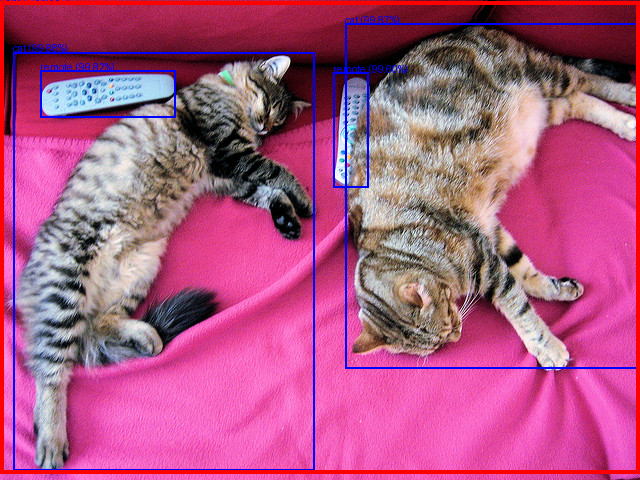

In [9]:
print("Testing object detection with a sample image")

# Test with a sample image from COCO dataset
test_url = "http://images.cocodataset.org/val2017/000000039769.jpg"
result = detect_largest_object(test_url, threshold=0.7)

if result:
    # Visualize the result
    vis_image = visualize_detection(result, show_all=True)
    display(vis_image)

#### [3 балла] Применение модели inpainting

In [4]:
#код

####[4 балла] Вывод результатов модели. Демо на gradio

In [5]:
#код

In [6]:
#демо grаdio

In [7]:
#визуализации